<a href="https://colab.research.google.com/github/majaVtech/business-sales-analysis/blob/main/Notebooks/northstar_retail_sales_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Northstar Retail --- Sales Analysis 2025**

## **1. Business Objective**

#### Objective

The objective of this analysis is to evaluate Northstar Retail's 2025 sales performance, identify data quality issues, calculate key business KPIs, analyze sales patterns, and provide actionable business recommendations.

#### **Business Questions**

The analysis aims to answer the following questions:

1. How reliable is the available sales data?
2. How much revenue did Northstar Retail generate in 2025?
3. How did revenue and sales volume change throughout the year?
4. Which product categories generate the most revenue?
5. Which products generate the most revenue and sales volume?
6. Which customers contribute the most revenue?
7. How does sales performance vary by city?
8. How do payment methods relate to sales performance?
9. How are discounts associated with revenue and average order value?
10. What actions could improve future business performance?

## **2. Import Libraries**


In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## **3. Load Raw Data**

In [116]:
# Importing  url as location to git repository raw data file
url = "https://raw.githubusercontent.com/majaVtech/business-sales-analysis/main/Data/raw_sales_data.csv"

df = pd.read_csv(url)

df.head()

,order_id,order_date,customer_id,customer_name,product,category,quantity,unit_price,discount,city,payment_method
0,ORD17439,2025-01-01,CUST0044,Customer 0044,Coffee Maker,Home & Kitchen,3,93.21,0.00,Sarajevo,PayPal
1,ORD11153,2025-01-01,CUST0256,Customer 0256,Skincare Set,Beauty,5,40.14,0.15,Doboj,Cash on Delivery
2,ORD05185,2025-01-01,CUST0392,Customer 0392,Printer,Office Supplies,2,142.94,0.00,Mostar,Cash on Delivery
3,ORD00849,2025-01-01,CUST0369,Customer 0369,Coffee Maker,Home & Kitchen,4,92.24,0.00,Mostar,Cash on Delivery
4,ORD07394,2025-01-01,CUST0269,Customer 0269,Running Shoes,Sports,3,86.09,0.15,Banja Luka,Credit Card


#### Dataset Overview

In [117]:
print("Shape:", df.shape)
print("-"*50)
df.info()
print("-"*50)
df.describe(include="all")

Shape: (20050, 11)
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20050 entries, 0 to 20049
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        20050 non-null  object 
 1   order_date      20050 non-null  object 
 2   customer_id     20050 non-null  object 
 3   customer_name   20050 non-null  object 
 4   product         20050 non-null  object 
 5   category        20050 non-null  object 
 6   quantity        20050 non-null  int64  
 7   unit_price      20050 non-null  float64
 8   discount        20050 non-null  float64
 9   city            19950 non-null  object 
 10  payment_method  19974 non-null  object 
dtypes: float64(2), int64(1), object(8)
memory usage: 1.7+ MB
--------------------------------------------------


,order_id,order_date,customer_id,customer_name,product,category,quantity,unit_price,discount,city,payment_method
count,20050,20050,20050,20050,20050,20050,20050.000000,20050.00000,20050.000000,19950,19974
unique,20000,365,500,500,14,12,NaN,NaN,NaN,10,4
top,ORD17229,2025-09-28,CUST0401,Customer 0401,Wireless Mouse,Electronics,NaN,NaN,NaN,Banja Luka,Credit Card
freq,2,82,56,56,2976,7291,NaN,NaN,NaN,4484,8918
mean,NaN,NaN,NaN,NaN,NaN,NaN,1.753367,91.33793,0.052581,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,1.030518,97.13023,0.059914,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,-1.000000,-50.00000,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,30.32250,0.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,73.15500,0.050000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,93.95000,0.100000,NaN,NaN


## **4. Data Quality Assessment**

### **4.1 Missing Values**

In [118]:
df.isna().sum()

,0
order_id,0
order_date,0
customer_id,0
customer_name,0
product,0
category,0
quantity,0
unit_price,0
discount,0
city,100


### **4.2 Duplicate Records**

In [119]:
print("Duplicated rows in dataset:", df.duplicated().sum())

Duplicated rows in dataset: 50


### **4.3 Categorical Value Consistency**

In [120]:
df['category'].value_counts(dropna=False)

,count
category,
Electronics,7291
Home & Kitchen,3621
Furniture,3048
Office Supplies,2204
Sports,2194
Beauty,1592
ELECTRONICS,32
FURNITURE,20
HOME & KITCHEN,17


### **4.4 Numerical Value Consistency**

In [121]:
print("Negative quantities:", (df['quantity'] < 0).sum())
print("Negativ prices:", (df['unit_price'] < 0).sum())
print("Negativ discount:", (df['discount'] < 0).sum())

Negative quantities: 10
Negativ prices: 5
Negativ discount: 0


#### Data Quality Summary

The initial assessment identified several data quality issues, including duplicate records, missing city and payment method values, inconsistent category capitalization, and invalid negative values in numerical fields. These issues were addressed before calculating business KPIs and performing the sales analysis.

## **5. Data Cleaning**

Create a srparate copy so that the original dataset remains unchanged.

In [122]:
df_clean = df.copy()

### **5.1 Remove Complete Duplicates**

In [123]:
df_clean = df_clean.drop_duplicates()

### **5.2 Remove Invalid Transactions**

In [124]:
df_clean = df_clean[
    (df_clean['quantity'] >= 0) &
    (df_clean['unit_price'] >= 0)
].copy()

### **5.2 Standardize Categories**

In [125]:
df_clean['category'] = (
    df['category']
    .str.strip()
    .str.lower()
)

### **5.4 Convert Order Data**

In [126]:
df_clean['order_date'] = pd.to_datetime(
    df_clean['order_date'],
    errors='coerce'
)

### **5.5 Validate Cleaning**

In [127]:
print("Shape after cleaning:", df_clean.shape)
print("\nNegatve quantities:", (df_clean['quantity'] < 0).sum())
print("\nMissing values:")
print(df_clean.isna().sum())

Shape after cleaning: (19985, 11)

Negatve quantities: 0

Missing values:
order_id            0
order_date          0
customer_id         0
customer_name       0
product             0
category            0
quantity            0
unit_price          0
discount            0
city              100
payment_method     75
dtype: int64


## **6. Feature Engineering**

### **6.1 Calculate Revenue**

In [128]:
df_clean['revenue'] = (
    df_clean['quantity']
    * df_clean['unit_price']
    * (1 - df_clean['discount'])
)

### **6.2 Creat Month Variables**

In [129]:
df_clean['month'] = df_clean['order_date'].dt.month

df_clean['month_name'] = df_clean['order_date'].dt.month_name()

## **7. Key Business KIPs**


In [130]:
total_revenue = df_clean["revenue"].sum()
total_orders = df_clean["order_id"].nunique()
units_sold = df_clean["quantity"].sum()

average_order_value = total_revenue / total_orders
average_revenue_per_unit = total_revenue / units_sold

print(f"Total Revenue: {total_revenue:,.2f} KM")
print(f"Total Orders: {total_orders:,}")
print(f"Units Sold: {units_sold:,}")
print(f"Average Order Value: {average_order_value:,.2f} KM")
print(f"Average Revenue per Unit: {average_revenue_per_unit:,.2f} KM")

Total Revenue: 3,029,371.64 KM
Total Orders: 19,985
Units Sold: 35,064
Average Order Value: 151.58 KM
Average Revenue per Unit: 86.40 KM


## **8. Monthly Sales Analysis**

In [131]:
monthly_sales = (
    df_clean
    .groupby('month_name')
    .agg(
        revenue=('revenue', 'sum'),
        orders=('order_id', 'nunique'),
        units_sold=('quantity', 'sum')
    )
    .reset_index()
)

Crete month name in chronological ordering

In [132]:
month_order = [ "January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December" ]
monthly_sales['month_name'] = (
    pd.Categorical(
        df_clean.groupby('month')['month_name'].first().values,
        categories=month_order,
        ordered=True
    )
)

monthly_sales

,month_name,revenue,orders,units_sold
0,January,256013.9680,1656,2872
1,February,272666.2900,1694,2997
2,March,260598.4205,1673,2884
3,April,234553.2895,1509,2723
4,May,268821.9100,1738,3084
5,June,236614.7690,1656,2903
6,July,243655.5245,1646,2894
7,August,247065.1645,1713,2966
8,September,258112.1755,1674,2894
9,October,254620.9550,1670,2958


### Monthly Revenue

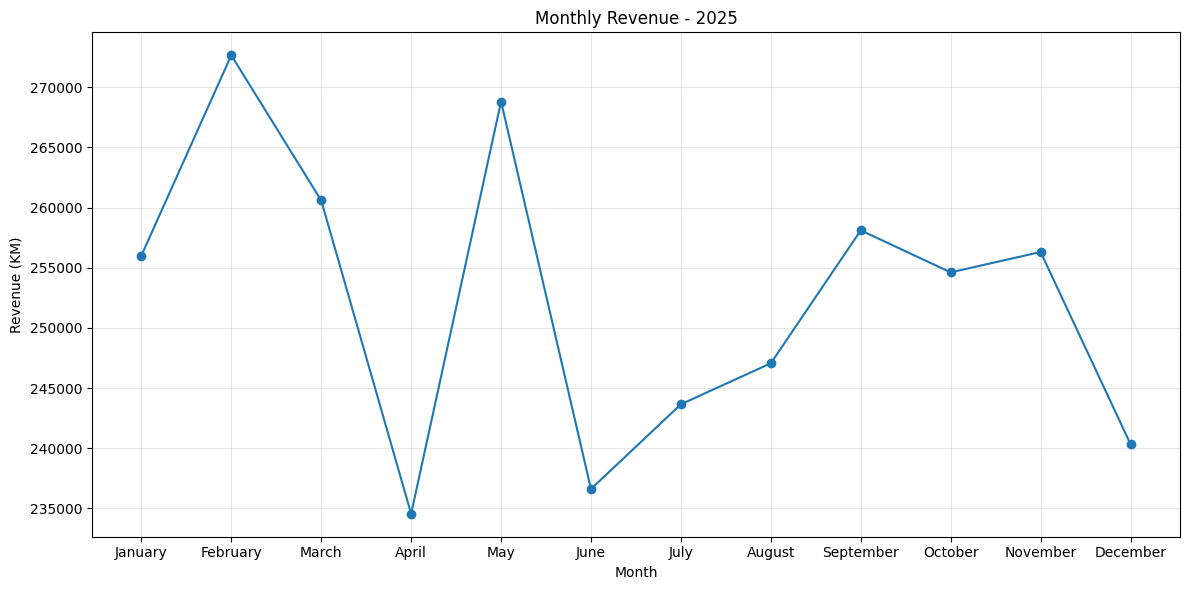

In [133]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales['month_name'],
    monthly_sales['revenue'],
    marker= 'o'
)

plt.title("Monthly Revenue - 2025")
plt.xlabel("Month")
plt.ylabel("Revenue (KM)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Key Finding

- Highest revenue: August — $272,666

- Lowest revenue: February — $234,553

Revenue remained relatively stable throughout the year.

## **9. Revenue by Category**

In [134]:
revenue_by_category = (
    df_clean
    .groupby('category')
    .agg(
        revenue=('revenue', 'sum'),
        orders=('order_id', 'nunique'),
        units_sold=('quantity', 'sum')
    )
    .reset_index()
    .sort_values('revenue', ascending=False)
)
revenue_by_category['revenue'] = revenue_by_category['revenue'].round(2)

revenue_by_category

,category,revenue,orders,units_sold
1,electronics,1212669.42,7300,12890
2,furniture,619382.34,3056,5339
3,home & kitchen,618000.22,3628,6303
5,sports,226123.12,2198,3835
4,office supplies,213973.97,2211,3849
0,beauty,139222.57,1592,2848


#### Revenue Share

In [135]:
revenue_by_category['share_revenue'] = (
    revenue_by_category['revenue']
    / total_revenue * 100
).round(2)

revenue_by_category

,category,revenue,orders,units_sold,share_revenue
1,electronics,1212669.42,7300,12890,40.03
2,furniture,619382.34,3056,5339,20.45
3,home & kitchen,618000.22,3628,6303,20.40
5,sports,226123.12,2198,3835,7.46
4,office supplies,213973.97,2211,3849,7.06
0,beauty,139222.57,1592,2848,4.60


#### Visualization

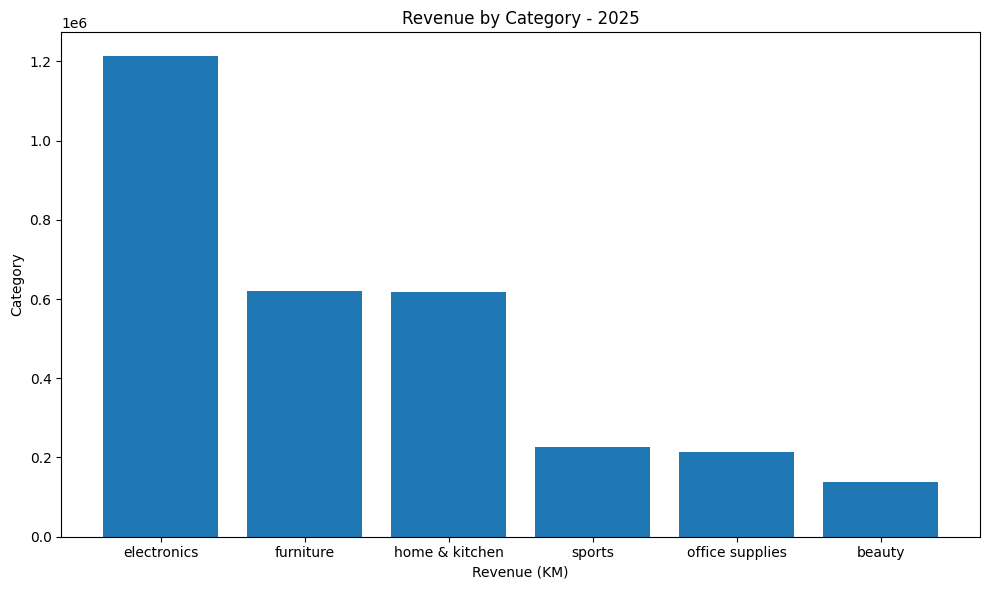

In [136]:
plt.figure(figsize=(10, 6))

plt.bar(
    revenue_by_category['category'],
    revenue_by_category['revenue']
)

plt.title("Revenue by Category - 2025")
plt.xlabel("Revenue (KM)")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

#### Key Finding

Electronics generated approximately **1.21 million**, making it the largest revenue-generating category.

## **10. Product Analysis**

### **10.1 Top Products by Revenue**

In [137]:
revenue_by_product = (
    df_clean
    .groupby('product')
    .agg(
        revenue=('revenue', 'sum'),
        orders=('order_id', 'nunique'),
        units_sold=('quantity', 'sum')
    )
    .reset_index()
    .sort_values('revenue', ascending=False)
)

top_products = revenue_by_product.head(10)

top_products

,product,revenue,orders,units_sold
11,Smartphone,664732.3665,804,1401
7,Office Chair,497534.8040,1585,2768
0,Air Fryer,319511.9835,1622,2802
2,Coffee Maker,298488.2410,2006,3501
5,Mechanical Keyboard,263216.4335,1955,3469
8,Printer,200155.6045,807,1413
9,Running Shoes,176345.9695,1192,2073
1,Bluetooth Speaker,162232.2420,1573,2851
12,Wireless Mouse,122488.3735,2968,5169
3,Desk Lamp,121847.5350,1471,2571


#### Visualization

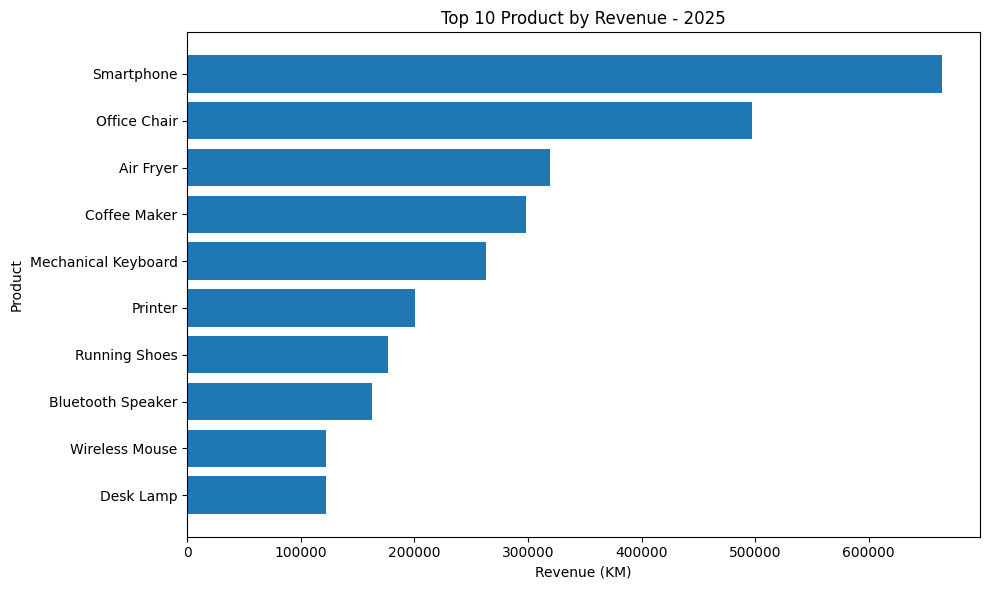

In [138]:
from matplotlib import color_sequences
plt.figure(figsize=(10, 6))

plt.barh(
    top_products['product'],
    top_products['revenue'],
)

plt.title("Top 10 Product by Revenue - 2025")
plt.xlabel("Revenue (KM)")
plt.ylabel("Product")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### **10.2 Top Products by Units Sold**

In [139]:
top_products_units = (
    df_clean
    .groupby("product")
    .agg(
        units_sold=("quantity", "sum"),
        orders=("order_id", "nunique"),
        revenue=("revenue", "sum")
    )
    .reset_index()
    .sort_values("units_sold", ascending=False)
    .head(10)
)

top_products_units

,product,units_sold,orders,revenue
12,Wireless Mouse,5169,2968,122488.3735
2,Coffee Maker,3501,2006,298488.2410
5,Mechanical Keyboard,3469,1955,263216.4335
1,Bluetooth Speaker,2851,1573,162232.2420
0,Air Fryer,2802,1622,319511.9835
7,Office Chair,2768,1585,497534.8040
3,Desk Lamp,2571,1471,121847.5350
6,Notebook,2436,1404,13818.3685
9,Running Shoes,2073,1192,176345.9695
13,Yoga Mat,1762,1006,49777.1555


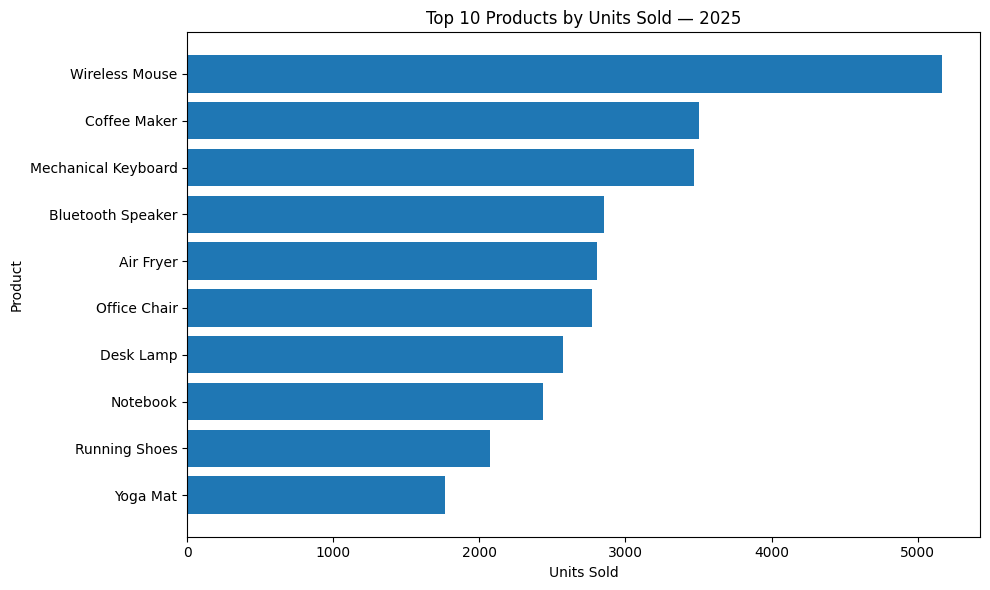

In [140]:
plt.figure(figsize=(10, 6))
plt.barh( top_products_units["product"], top_products_units["units_sold"] )
plt.title("Top 10 Products by Units Sold — 2025")
plt.xlabel("Units Sold")
plt.ylabel("Product")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#### Key Finding

The **Smartphone** generated the highest revenue, while the **Wireless Mouse** had the highest sales volume.

This demonstrates why both revenue and units sold should be considered when evaluating product performance.

## **11. Customer Analysis**

### **11.1 Top Customers by Revenue**

In [141]:
customer_analysis = (
    df_clean
    .groupby(['customer_id', 'customer_name'])
    .agg(
        revenue=('revenue', 'sum'),
        orders=('order_id', 'nunique'),
        units_sold=('quantity', 'sum')
    )
    .reset_index()
    .sort_values('revenue', ascending=False)
)

top_customers_revenue = customer_analysis.head(10)
top_customers_revenue

,customer_id,customer_name,revenue,orders,units_sold
386,CUST0387,Customer 0387,12503.6120,47,95
100,CUST0101,Customer 0101,12360.5245,48,108
36,CUST0037,Customer 0037,10966.5900,41,73
83,CUST0084,Customer 0084,10719.8765,51,95
399,CUST0400,Customer 0400,10371.1940,55,104
327,CUST0328,Customer 0328,10183.8335,40,67
404,CUST0405,Customer 0405,9988.6590,55,108
130,CUST0131,Customer 0131,9866.1865,48,80
254,CUST0255,Customer 0255,9855.0805,51,97
87,CUST0088,Customer 0088,9733.3400,48,88


#### Visualization

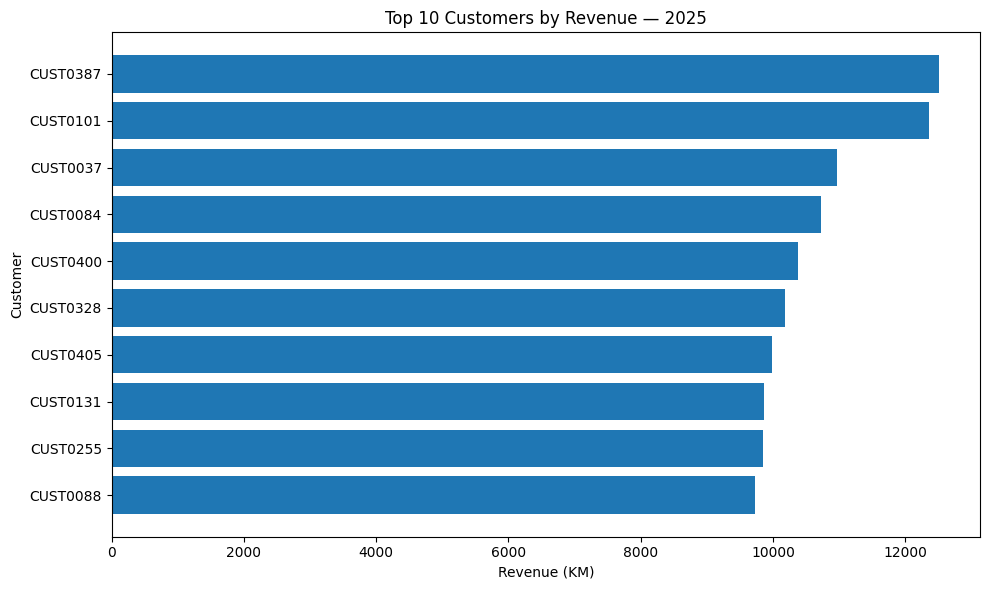

In [142]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_customers_revenue["customer_id"],
    top_customers_revenue["revenue"]
    )

plt.title("Top 10 Customers by Revenue — 2025")
plt.xlabel("Revenue (KM)")
plt.ylabel("Customer")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### **11.2 Customer Average Order Value**

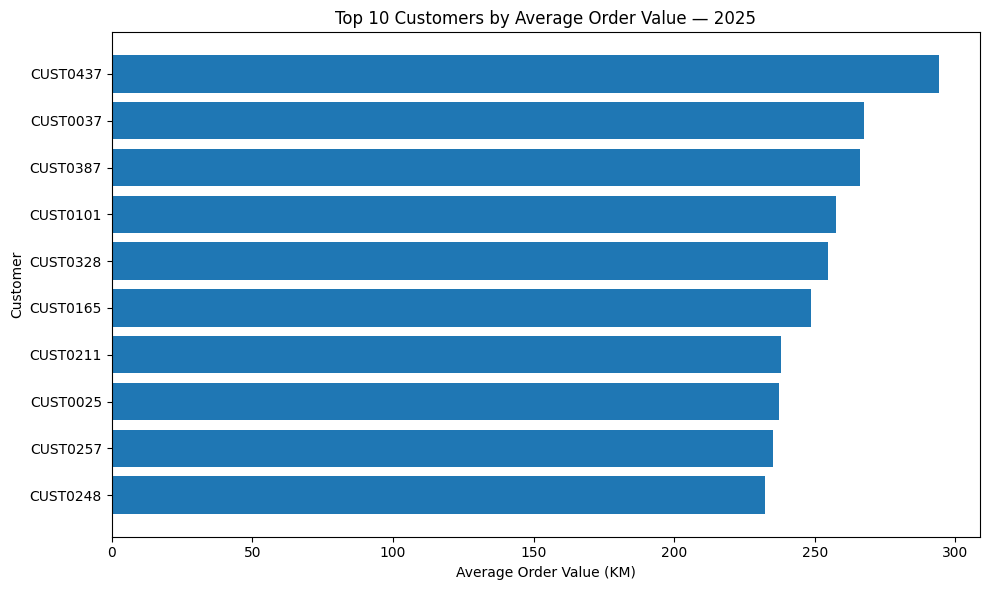

In [143]:
customer_analysis['avg_order_value'] = (
    customer_analysis['revenue']
    / customer_analysis['orders']
)

top_customers_aov = (
    customer_analysis
    .sort_values('avg_order_value', ascending=False)
    .head(10)
)
top_customers_aov

plt.figure(figsize=(10, 6))

plt.barh(
    top_customers_aov["customer_id"],
    top_customers_aov["avg_order_value"]
    )

plt.title("Top 10 Customers by Average Order Value — 2025")
plt.xlabel("Average Order Value (KM)")
plt.ylabel("Customer")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## **12. Sales by City**

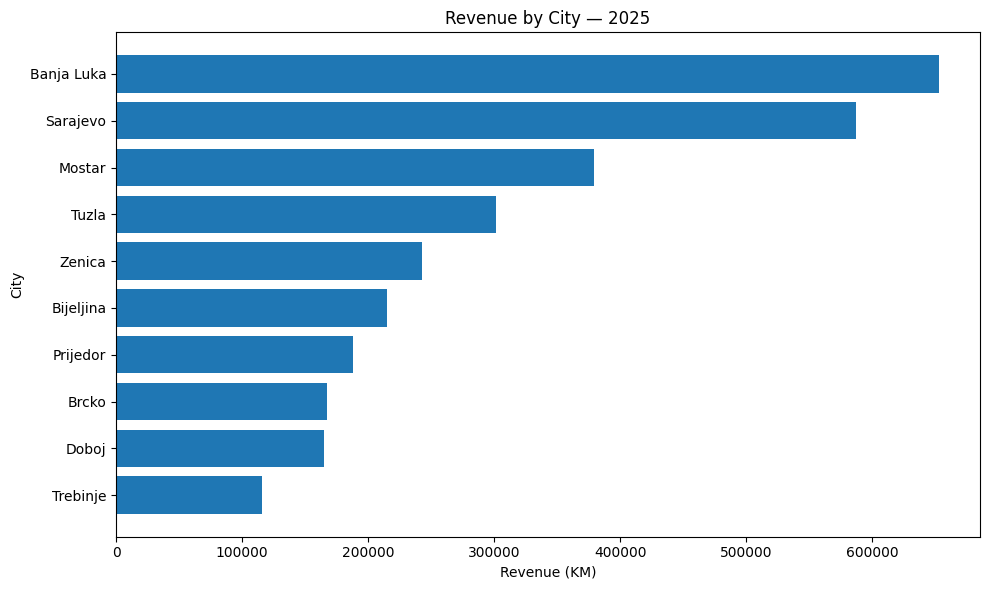

In [144]:
revenue_by_city = (
    df_clean
    .groupby('city')
    .agg(
        revenue=('revenue', 'sum'),
        orders=('order_id', 'nunique'),
        units_sold=('quantity', 'sum')
    )
    .reset_index()
    .sort_values('revenue', ascending=False)
)

revenue_by_city

# Visualization

plt.figure(figsize=(10, 6))

plt.barh(
    revenue_by_city["city"],
    revenue_by_city["revenue"]
    )

plt.title("Revenue by City — 2025")
plt.xlabel("Revenue (KM)")
plt.ylabel("City")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



### **12.1 Average Order Value by City**

In [145]:
revenue_by_city['avg_order_value'] = (
    revenue_by_city['revenue']
    / revenue_by_city['orders']
)

city_aov = revenue_by_city.sort_values(
    'avg_order_value',
    ascending=False
)

city_aov

,city,revenue,orders,units_sold,avg_order_value
3,Doboj,164776.2520,1057,1845,155.890494
4,Mostar,379490.0750,2440,4294,155.528719
9,Zenica,242411.6735,1559,2701,155.491773
1,Bijeljina,215088.6745,1392,2412,154.517726
5,Prijedor,188307.9285,1220,2163,154.350761
6,Sarajevo,587007.5920,3823,6877,153.546323
7,Trebinje,115436.0700,752,1327,153.505412
8,Tuzla,301274.9745,2008,3528,150.037338
0,Banja Luka,652657.7715,4466,7709,146.139223
2,Brcko,167253.0830,1168,2039,143.196133


#### Key Finding

Banja Luka generated the highest total revenue, while Doboj had the highest average order value.

This suggests that Banja Luka's revenue is primarily driven by a larger number of orders.

## **13. Payment Method Analysis**

In [146]:
payment_analysis = (
    df_clean
    .groupby('payment_method')
    .agg(
        revenue=('revenue', 'sum'),
        orders=('order_id', 'nunique'),
        units_sold=('quantity', 'sum')
    )
    .reset_index()
)
payment_analysis['revenue'] = payment_analysis['revenue'].round(2)

payment_analysis

,payment_method,revenue,orders,units_sold
0,Bank Transfer,442324.30,3007,5231
1,Cash on Delivery,457880.75,3052,5370
2,Credit Card,1339945.89,8891,15609
3,PayPal,770796.67,4960,8712


### **13.1 Revenue by Payment Method**

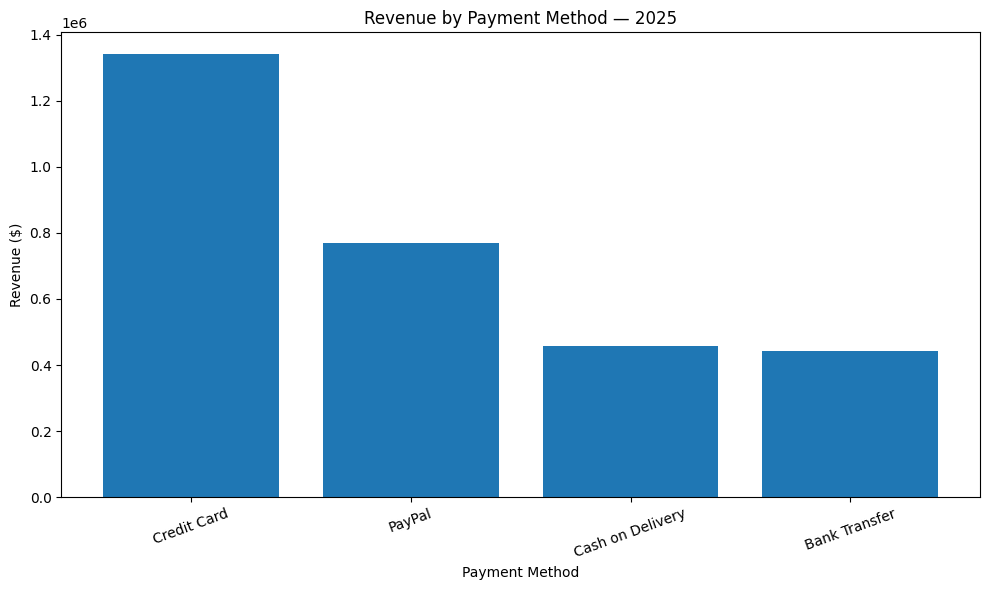

In [147]:
payment_analysis = payment_analysis.sort_values(
    "revenue",
    ascending=False
)
plt.figure(figsize=(10, 6))

plt.bar(
    payment_analysis["payment_method"],
    payment_analysis["revenue"]
)

plt.title("Revenue by Payment Method — 2025")
plt.xlabel("Payment Method")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### **13.2 Average Order Value**

In [148]:
payment_analysis["avg_order_value"] = (
    payment_analysis["revenue"]
    / payment_analysis["orders"]
)

payment_aov = payment_analysis.sort_values(
    'avg_order_value',
    ascending=False
)

payment_aov


,payment_method,revenue,orders,units_sold,avg_order_value
3,PayPal,770796.67,4960,8712,155.402554
2,Credit Card,1339945.89,8891,15609,150.708119
1,Cash on Delivery,457880.75,3052,5370,150.026458
0,Bank Transfer,442324.30,3007,5231,147.098204


#### Key Finding

Credit Card generated the highest total revenue, while PayPal had the highest average order value. The difference between payment methods was relatively small.

## **14. Discount Analysis**

In [149]:
discount_analysis = (
    df_clean
    .groupby('discount')
    .agg(
        revenue=('revenue', 'sum'),
        orders=('order_id', 'nunique'),
        units_sold=('quantity', 'sum')
    )
    .reset_index()
    .sort_values('discount')
)

discount_analysis['avg_order_value'] =(
    discount_analysis['revenue']
    / discount_analysis['orders']
)

discount_analysis['revenue_share'] = (
    discount_analysis['revenue']
    / total_revenue * 100
).round(2)
discount_analysis['discount_pct'] = (
    discount_analysis['discount'] * 100
)
discount_analysis['revenue'] = discount_analysis['revenue'].round(2)

discount_analysis

,discount,revenue,orders,units_sold,avg_order_value,revenue_share,discount_pct
0,0.00,1445619.34,8952,15611,161.485628,47.72,0.0
1,0.05,747758.02,5004,8833,149.432057,24.68,5.0
2,0.10,441330.02,3034,5328,145.461444,14.57,10.0
3,0.15,272607.16,2040,3611,133.630962,9.00,15.0
4,0.20,122057.10,955,1681,127.808486,4.03,20.0


### **14.1 Revenue by Discount**

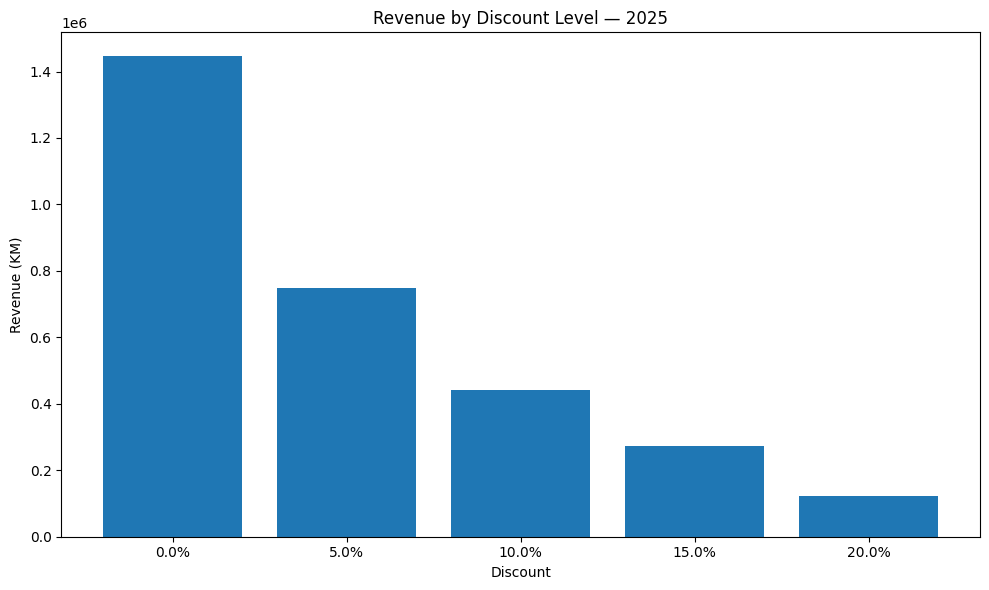

In [150]:
plt.figure(figsize=(10, 6))
plt.bar(
    discount_analysis["discount_pct"].astype(str) + "%",
    discount_analysis["revenue"]
    )

plt.title("Revenue by Discount Level — 2025")
plt.xlabel("Discount")
plt.ylabel("Revenue (KM)")
plt.tight_layout()
plt.show()

### **14.2 Average Order Value by Discount**

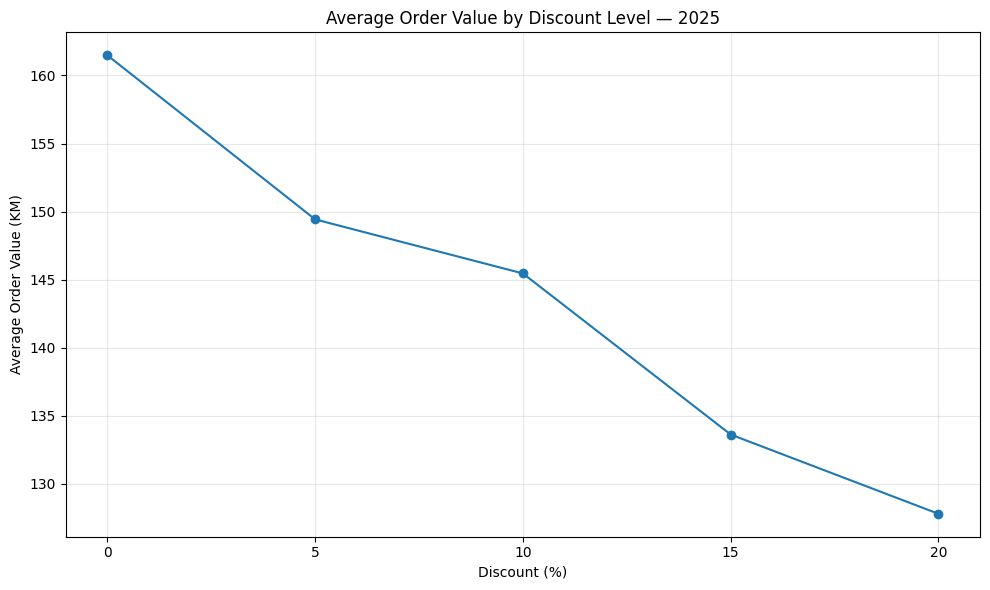

In [151]:
plt.figure(figsize=(10, 6))

plt.plot(
    discount_analysis["discount_pct"],
    discount_analysis["avg_order_value"],
    marker="o"
    )

plt.title("Average Order Value by Discount Level — 2025")
plt.xlabel("Discount (%)")
plt.ylabel("Average Order Value (KM)")
plt.xticks(discount_analysis["discount_pct"])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Key Finding

Orders without discounts generated approximately 47.7% of total revenue and had an average order value of approximately 161KM.

At a 20% discount, average order value decreased to approximately 128KM.

This indicates an association between higher discount levels and lower average order values, although the analysis does not establish causation.

## **15. Business Insights & Recommendations**
### Business Insights
####**1. Revenue remained relatively stable**

Northstar Retail generated approximately **3.03 million (KM)** in revenue from 19,985 orders.

August was the strongest month with approximately **272,666KM**, while February was the weakest with approximately **234,553KM**.

#### **2. Electronics is the leading category**

Electronics generated approximately **1.21 million (KM)**, making it the largest contributor to total revenue.

#### **3. High revenue and high sales volume are different concepts**

The Smartphone generated the highest product revenue, while the Wireless Mouse generated the highest unit volume.

This shows that product performance should be evaluated using multiple metrics.

#### **4. Banja Luka has the highest total revenue**

Banja Luka generated approximately **653,000KM**, but its average order value was approximately **146KM**.

The city's strong revenue performance is therefore primarily associated with order volume.

#### **5. Discounts should be monitored**

Higher discount levels were associated with lower average order values. Discounting should therefore be evaluated together with sales volume, product category, and profitability.

## **16. Recommendations**

#### **1. Prioritize high-value products**

Monitor inventory availability for products that contribute substantially to total revenue.

#### **2. Distinguish high-volume and high-value products**

Use both revenue and units sold when evaluating product performance.

#### **3. Increase order value in high-volume markets**

Investigate bundles, cross-selling, and complementary products in markets such as Banja Luka.

#### **4. Use discounts selectively**

Evaluate whether larger discounts generate enough additional sales to justify the reduction in price.

#### **5. Monitor monthly performance**

Track monthly revenue, orders, and units sold to identify weaker periods.

### **6. Improve data quality**

Introduce regular checks for duplicates, missing values, inconsistent categories, and invalid numerical values.

## **17. Measurable KPIs & Targets**

The following targets are proposed management objectives based on the 2025 baseline.

| KPI | 2025 Baseline | Proposed Target |
|---|---:|---:|
| **Total Revenue** | 3.03M(KM) | **+10%** |
| **Total Orders** | 19,985 | **21,000+** |
| **Average Order Value** | 151.58(KM) | **160+** |
| **Units Sold** | 35,064 | **37,000+** |
| **Electronics Revenue** | 1.21M(KM) | **+10%** |
| **Discounted Revenue Share** | 52.28% | **≤50%** |
| **Monthly Revenue** | 234.6K–272.7K(KM) | **≥250K** |
| **Data Quality Issues** | Multiple | **<1% critical-field issues** |

> **Note:** Proposed targets are management targets for future performance and are not directly derived from the historical dataset.

## KPI Monitoring

The recommended management dashboard should monitor:

- Total Revenue
- Total Orders
- Average Order Value
- Units Sold
- Monthly Revenue
- Revenue by Category
- Top Products
- Revenue by City
- Discounted Revenue Share
- Data Quality Rate

These KPIs should be reviewed monthly and compared with the proposed targets.


## **18. Final Conclusion**

Northstar Retail generated approximately **3.03 million (KM) in revenue across 19,985 orders during 2025**.

The analysis shows a relatively stable sales pattern, with Electronics representing the largest revenue category and several high-value products contributing substantially to overall revenue.

The analysis also demonstrates the importance of evaluating multiple business metrics. High sales volume does not necessarily correspond to high revenue, and strong total revenue in a city does not necessarily mean that customers have a higher average order value.

The main areas for future management attention are **high-value product management, increasing average order value, targeted use of discounts, and maintaining consistent data quality**.

The proposed KPI targets provide a measurable framework for monitoring progress and evaluating future business performance.